# Hybrid Discrete-Continuous Circuits

This notebook demonstrates hybrid probabilistic circuits that combine discrete (p-bit) and continuous random variables.

In [1]:
import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats


from torx import (
    draw_circuit,
    HybridPCircuit,
    HybridSampleSimulator,
    MixtureGaussianGate,
    PNOT,
    HybridPCircuit,
    HybridSampleSimulator,
    MixtureGaussianGate,
    PditCycle,
    draw_circuit,
)

## Mixture of Gaussians

The `MixtureGaussianGate` implements a Gaussian mixture model where a discrete site selects which component to sample from. Given discrete state $k$:

$$x' = x + \mu_k + \mathcal{N}(0, \sigma_k^2)$$

In [2]:
pnot = PNOT(jnp.array(0.0), sites=0)

mixture_gate = MixtureGaussianGate(
    theta={
        "means": jnp.array([[-3.0], [3.0]]),
        "log_vars": jnp.array([[-1.0], [-1.0]]),
    },
    sites=([0], [0]),
    dims=(1,),
)

circuit = HybridPCircuit([pnot, mixture_gate])

In [3]:
sim = HybridSampleSimulator(num_samples=10000)
key = jax.random.key(42)

initial_state = {"discrete": jnp.array([0]), "continuous": jnp.zeros(1)}

sample_fn = eqx.filter_jit(sim.sample)
result = sample_fn(circuit, initial_state, key)

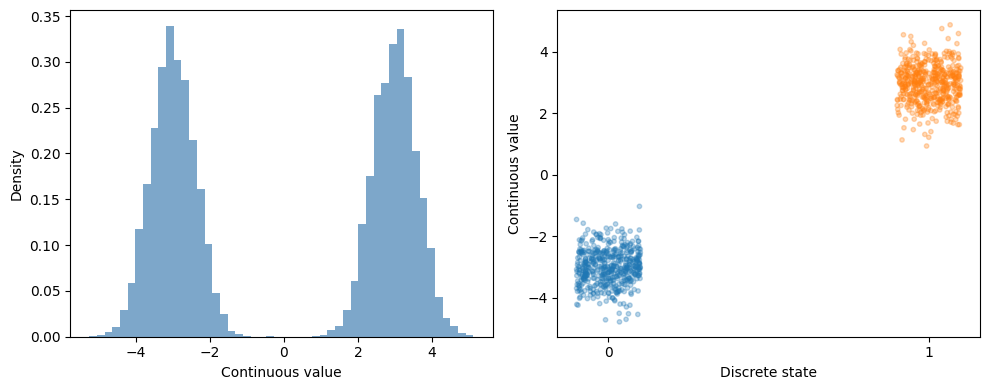

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(
    np.array(result["continuous"][:, 0]),
    bins=50,
    density=True,
    alpha=0.7,
    color="steelblue",
)
axes[0].set_xlabel("Continuous value")
axes[0].set_ylabel("Density")

discrete_vals = np.array(result["discrete"][:, 0])
continuous_vals = np.array(result["continuous"][:, 0])

n_plot = 1000
axes[1].scatter(
    discrete_vals[:n_plot] + np.random.uniform(-0.1, 0.1, n_plot),
    continuous_vals[:n_plot],
    alpha=0.3,
    s=10,
    c=["tab:blue" if d == 0 else "tab:orange" for d in discrete_vals[:n_plot]],
)
axes[1].set_xlabel("Discrete state")
axes[1].set_ylabel("Continuous value")
axes[1].set_xticks([0, 1])

plt.tight_layout()
plt.show()

In [5]:
num_samples = 5000
sim = HybridSampleSimulator(num_samples=num_samples)
sample_fn = eqx.filter_jit(sim.sample)

key = jax.random.key(123)
initial_state = {"discrete": jnp.array([0]), "continuous": jnp.zeros(1)}

step_counts = [1, 2, 5, 10, 20]
final_distributions = []

for num_steps in step_counts:
    circuit_reps = HybridPCircuit([pnot, mixture_gate], reps=num_steps)
    key, subkey = jax.random.split(key)
    result = sample_fn(circuit_reps, initial_state, subkey)
    final_distributions.append(np.array(result["continuous"][:, 0]))

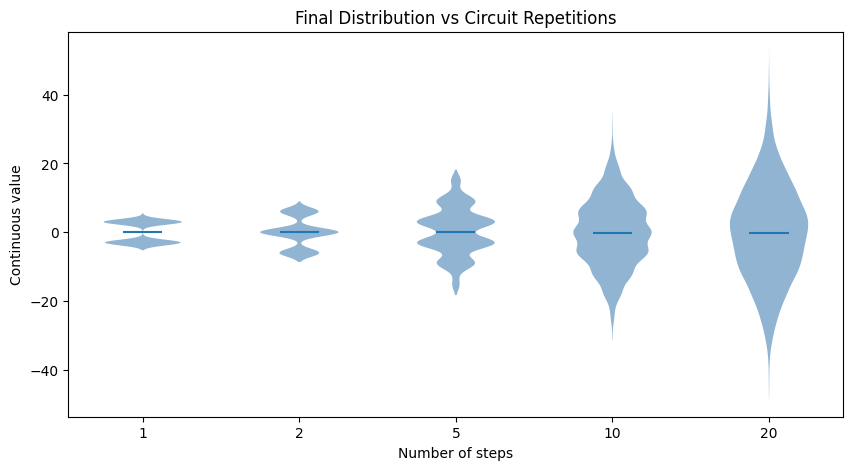

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

positions = list(range(len(step_counts)))
parts = ax.violinplot(
    final_distributions, positions=positions, showmeans=True, showextrema=False
)

for pc in parts["bodies"]:
    pc.set_facecolor("steelblue")
    pc.set_alpha(0.6)

ax.set_xlabel("Number of steps")
ax.set_ylabel("Continuous value")
ax.set_title("Final Distribution vs Circuit Repetitions")
ax.set_xticks(positions)
ax.set_xticklabels(step_counts)
plt.show()

## Jump-Diffusion Process

In [7]:
MU = jnp.array([1.0, 0.0, -0.8])  # drifts
SIGMA = jnp.array([0.3, 1.0, 0.5])  # volatilities
LAM_FWD = 0.5  # forward transition rate (0->1->2->0)
LAM_BWD = 0.3  # backward transition rate (0->2->1->0)
T_TOTAL = 10.0


def build_one_step(dt):
    p_fwd = LAM_FWD * dt
    p_bwd = LAM_BWD * dt
    p_stay = 1.0 - p_fwd - p_bwd
    theta_cycle = jnp.log(jnp.array([p_fwd, p_bwd]) / p_stay)
    means = (MU * dt)[:, None]
    log_vars = jnp.log(SIGMA**2 * dt)[:, None]
    return HybridPCircuit(
        [
            PditCycle(theta=theta_cycle, sites=0, dims=3),
            MixtureGaussianGate(
                theta={"means": means, "log_vars": log_vars},
                sites=([0], [0]),
                dims=(1,),
            ),
        ]
    )


draw_circuit(build_one_step(0.1))

     ┌───────────┐         
d_0: ┤ PditCycle ├───■─────
     └───────────┘   │     
                  ┌──┴──┐  
c_0: ═════════════╡ MoG ╞══
                  └─────┘  


In [8]:
dt_traj = 0.02
num_steps = int(T_TOTAL / dt_traj)
num_trajectories = 5000

circuit = build_one_step(dt_traj)
sim = HybridSampleSimulator(num_samples=1)


@eqx.filter_jit
def simulate_trajectories(keys):
    def step(state, key):
        result = sim.sample(circuit, state, key)
        new_state = {
            "discrete": result["discrete"][0],
            "continuous": result["continuous"][0],
        }
        return new_state, (new_state["discrete"][0], new_state["continuous"][0])

    def simulate_one(key):
        step_keys = jax.random.split(key, num_steps)
        init = {"discrete": jnp.array([0]), "continuous": jnp.zeros(1)}
        _, (regimes, positions) = jax.lax.scan(step, init, step_keys)
        return regimes, positions

    return jax.vmap(simulate_one)(keys)


keys = jax.random.split(jax.random.key(42), num_trajectories)
regimes, positions = simulate_trajectories(keys)
regimes, positions = np.array(regimes), np.array(positions)

In [9]:
dt_ref = 0.005
dt_coarse = np.logspace(-1.5, -0.5, 10)
num_samples_conv = 20000
sim = HybridSampleSimulator(num_samples=1)


def get_terminal(dt, key):
    circ = build_one_step(dt)
    n = int(T_TOTAL // dt)

    @eqx.filter_jit
    def _run(keys):

        def step(state, k):
            res = sim.sample(circ, state, k)
            return {
                "discrete": res["discrete"][0],
                "continuous": res["continuous"][0],
            }, None

        def one(k):
            ks = jax.random.split(k, n)
            final, _ = jax.lax.scan(
                step,
                {"discrete": jnp.array([0]), "continuous": jnp.zeros(1)},
                ks,
            )
            return final["continuous"][0]

        return jax.vmap(one)(keys)

    return _run(jax.random.split(key, num_samples_conv))


ref = get_terminal(dt_ref, jax.random.key(0))

ks_distances = []
for i, dt in enumerate(dt_coarse):
    print(i, dt)
    terminal = get_terminal(dt, jax.random.key(i + 1))
    ks_stat, _ = stats.ks_2samp(ref, terminal)
    ks_distances.append(ks_stat)

0 0.03162277660168379
1 0.04084238652674522
2 0.052749970637026196
3 0.06812920690579612
4 0.0879922543569107
5 0.11364636663857249
6 0.14677992676220694
7 0.18957356524063754
8 0.24484367468222268
9 0.31622776601683794


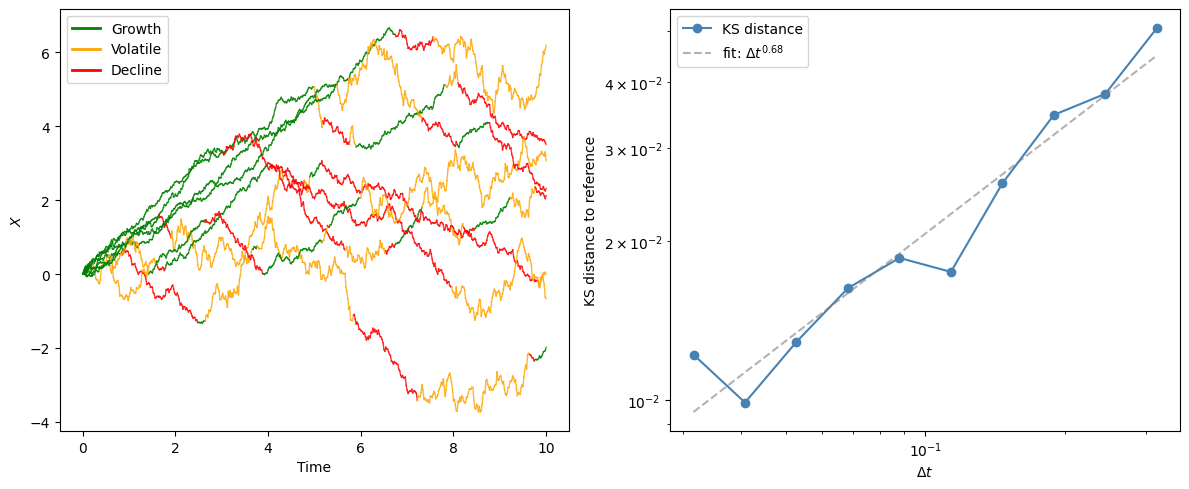

In [10]:
colors = ["green", "orange", "red"]
names = ["Growth", "Volatile", "Decline"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

time = np.arange(1, num_steps + 1) * dt_traj
n_show = 8
for i in range(n_show):
    x_full = np.concatenate([[0.0], positions[i]])
    t_full = np.concatenate([[0.0], time])
    for t in range(num_steps):
        c = colors[int(regimes[i, t])]
        axes[0].plot(
            t_full[t : t + 2], x_full[t : t + 2], color=c, linewidth=1.0, alpha=0.8
        )

for name, color in zip(names, colors):
    axes[0].plot([], [], color=color, linewidth=2, label=name)
axes[0].legend(loc="upper left")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("$X$")

dt_arr = np.array(dt_coarse)
ks_arr = np.array(ks_distances)
axes[1].loglog(dt_arr, ks_arr, marker="o", color="steelblue", label="KS distance")

m, b = np.polyfit(np.log(dt_arr), np.log(ks_arr), 1)
dt_fit = np.logspace(np.log10(dt_arr.min()), np.log10(dt_arr.max()), 100)
axes[1].loglog(
    dt_fit,
    np.exp(b) * dt_fit**m,
    "--",
    color="gray",
    alpha=0.6,
    label=rf"fit: $\Delta t^{{{m:.2f}}}$",
)
axes[1].set_xlabel(r"$\Delta t$")
axes[1].set_ylabel("KS distance to reference")
axes[1].legend()

plt.tight_layout()
plt.show()